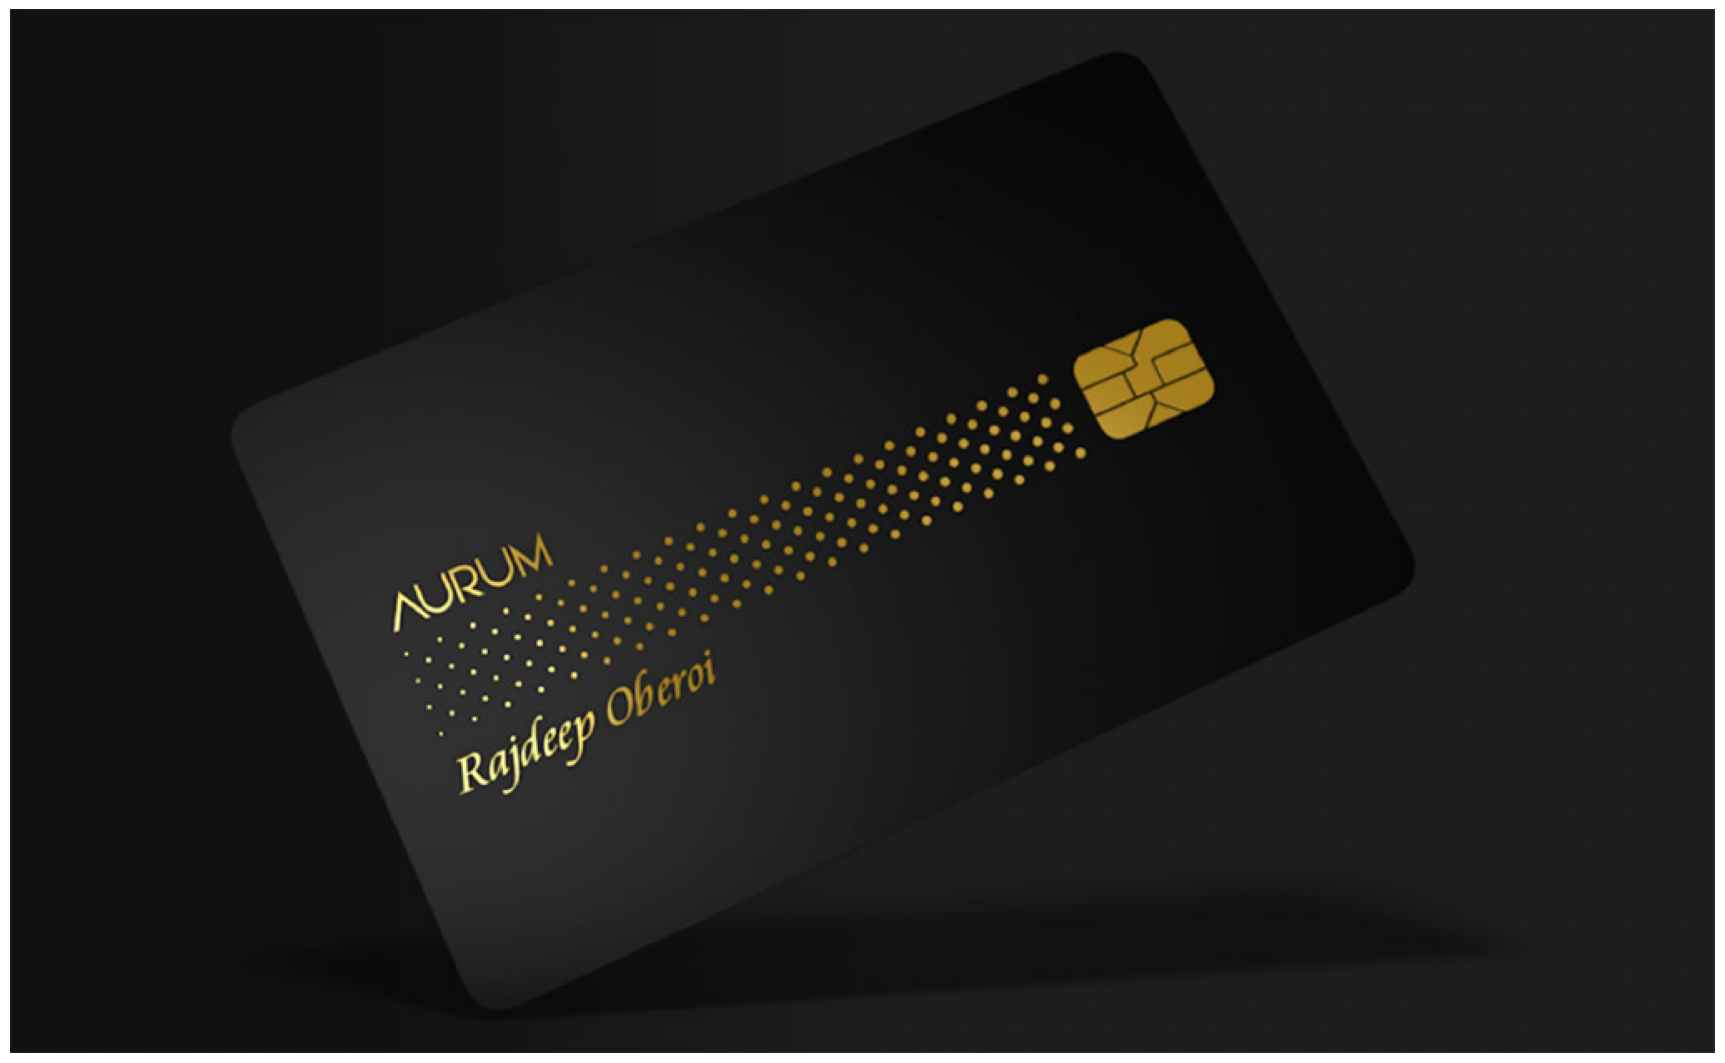

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread(r"C:\Users\niyas\OneDrive\Desktop\NIYAS DSA\sbicard-aurum-front-face.jpg")
plt.figure(figsize=(22,14))
plt.imshow(img)
plt.axis('off')
plt.show()


<div style="background-color: #121212; color: #b300ffff; font-weight: bold; padding: 18px; border-radius: 18px; text-align: center; font-size: 45px; box-shadow: 0 0 15px #b300ffff;">
CREDIT CARD CUSTOMER DATA
</div>

<div style="background-color:#111; color:#b300ffff; font-weight:700; padding:18px; border-radius:18px; text-align:center; font-size:30px; border:2px solid #b300ffff;">
 📚 IMPORT LIBRARIES, ALGORITHMS, AND METRICS
</div>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler

In [ ]:
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

import scipy.cluster.hierarchy as sch

import skfuzzy as fuzz

from tabulate import tabulate

<div style="background-color: #263238; color: #eceff1; font-weight: bold; padding: 7px; border-radius: 15px; text-align: center; font-size: 30px;">
LOAD DATASET
</div>

In [ ]:
df=pd.read_csv(r"C:\Users\niyas\OneDrive\Desktop\NIYAS DSA\PairDrop_files_2025  (CSV)\Credit Card Customer Data.csv")
df

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3
...,...,...,...,...,...,...,...
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0


<table style="border-collapse: collapse; width: 40%; font-size: 15px; color:black;">

  <!-- Heading -->
  <tr style="background-color:#b7e4c7; text-align:center;">
    <th style="padding:10px;">Feature Name</th>
    <th style="padding:10px; background-color:#b7e4c7;">
      Simple Explanation
    </th>
  </tr>

  <tr style="background-color:#e9f5ff;">
    <td style="padding:10px;"><b>Sl_No</b></td>
    <td style="padding:15px; background-color:#e9f5ff;">
      Serial number of the record
    </td>
  </tr>

  <tr style="background-color:#e9f5ff;">
    <td style="padding:10px;"><b>Customer Key</b></td>
    <td style="padding:15px; background-color:#e9f5ff;">
      Unique ID for each customer
    </td>
  </tr>

  <tr style="background-color:#e9f5ff;">
    <td style="padding:10px;"><b>Avg_Credit_Limit</b></td>
    <td style="padding:15px; background-color:#e9f5ff;">
      Average credit limit of the customer
    </td>
  </tr>

  <tr style="background-color:#e9f5ff;">
    <td style="padding:10px;"><b>Total_Credit_Cards</b></td>
    <td style="padding:15px; background-color:#e9f5ff;">
      Total number of credit cards owned
    </td>
  </tr>

  <tr style="background-color:#e9f5ff;">
    <td style="padding:10px;"><b>Total_visits_bank</b></td>
    <td style="padding:15px; background-color:#e9f5ff;">
      Number of visits made to the bank
    </td>
  </tr>

  <tr style="background-color:#e9f5ff;">
    <td style="padding:10px;"><b>Total_visits_online</b></td>
    <td style="padding:15px; background-color:#e9f5ff;">
      Number of online banking visits
    </td>
  </tr>

  <tr style="background-color:#e9f5ff;">
    <td style="padding:10px;"><b>Total_calls_made</b></td>
    <td style="padding:15px; background-color:#e9f5ff;">
      Number of calls made to the bank
    </td>
  </tr>

</table>


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [ ]:
df.describe()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000
mean,330.500000,55141.443939,34574.242424,4.706061,2.403030,2.606061,3.583333
std,190.669872,25627.772200,37625.487804,2.167835,1.631813,2.935724,2.865317
min,1.000000,11265.000000,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,165.750000,33825.250000,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,330.500000,53874.500000,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,495.250000,77202.500000,48000.000000,6.000000,4.000000,4.000000,5.000000
max,660.000000,99843.000000,200000.000000,10.000000,5.000000,15.000000,10.000000


In [ ]:
for i in df:
    print(i,' :')
    print(df[i].unique())
    print('\n')
    print(df[i].nunique())
    print('\n\n\n\n')

Sl_No  :
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 244 2

<div style="background-color:#111; color:#b300ffff; font-weight:700; padding:18px; border-radius:18px; text-align:center; font-size:40px; border:2px solid #b300ffff;">
DATA-PREPROCESSING
</div>

In [ ]:
df.isna().sum()

Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

In [ ]:
df=df.drop(['Sl_No','Customer Key'],axis=1)
df

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,100000,2,1,1,0
1,50000,3,0,10,9
2,50000,7,1,3,4
3,30000,5,1,1,4
4,100000,6,0,12,3
...,...,...,...,...,...
655,99000,10,1,10,0
656,84000,10,1,13,2
657,145000,8,1,9,1
658,172000,10,1,15,0


<div style="background-color: #263238; color: #eceff1; font-weight: bold; padding: 5px; border-radius: 15px; text-align: center; font-size: 30px;">
SCALING
</div>

In [ ]:
scaler=RobustScaler()
scaled=scaler.fit_transform(df)

<div style="background-color: #263238; color: #eceff1; font-weight: bold; padding: 5px; border-radius: 15px; text-align: center; font-size: 30px;">
PCA
</div>

In [ ]:
pca=PCA(n_components=2)
pca_data=pca.fit_transform(df)

In [ ]:
pca=PCA(n_components=2)
pca_scaled=pca.fit_transform(scaled)

<div style="background-color: #263238; color: #eceff1; font-weight: bold; padding: 5px; border-radius: 15px; text-align: center; font-size: 30px;">
K-MEANS
</div>

  File "c:\Users\niyas\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\niyas\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\niyas\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\niyas\anaconda3\Lib\subprocess.

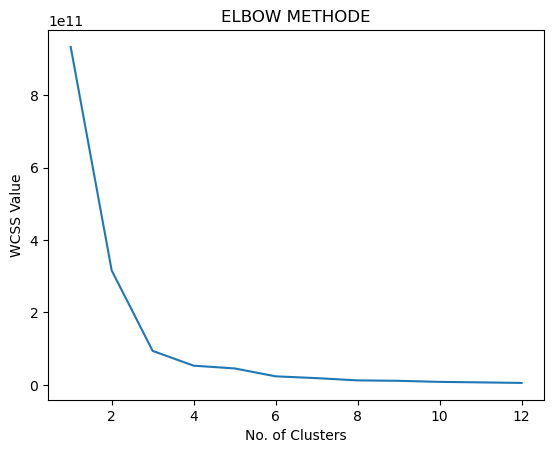

In [ ]:
wcss=[]

for i in range(1,13):
    kmeans=KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans=kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,13),wcss)
plt.title('ELBOW METHODE')
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS Value')
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=2, init='k-means++', random_state=42)
y_kmeans=kmeans.fit_predict(pca_data)
s=silhouette_score(pca_data,y_kmeans)
s

np.float64(0.7701124313202523)

In [ ]:
y_kmeans

array([1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

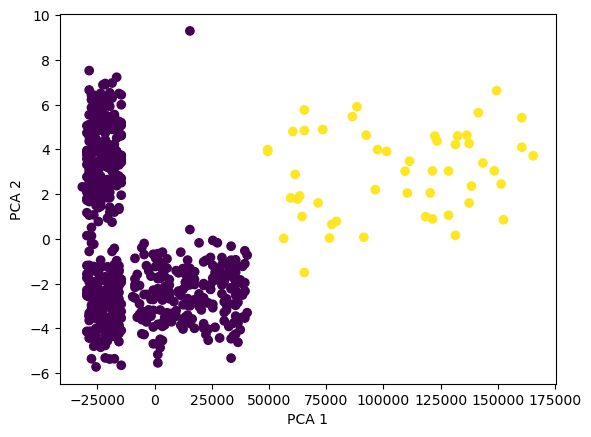

In [ ]:
pca=PCA(n_components=2)
df2_reduced=pca.fit_transform(pca_data)

plt.scatter(df2_reduced[:,0], df2_reduced[:,1], c=kmeans.labels_)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

<div style="background-color: #263238; color: #eceff1; font-weight: bold; padding: 5px; border-radius: 15px; text-align: center; font-size: 30px;">
DBSCAN CLUSTERING
</div>

In [ ]:
epsilon=0.8
min_sample=9
dbscan=DBSCAN(eps=epsilon,min_samples=min_sample)
labels=dbscan.fit_predict(pca_scaled)
s_db=silhouette_score(pca_scaled,labels)
s_db

np.float64(0.6800795150826543)

In [ ]:
labels

array([ 0, -1,  0,  0,  1,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

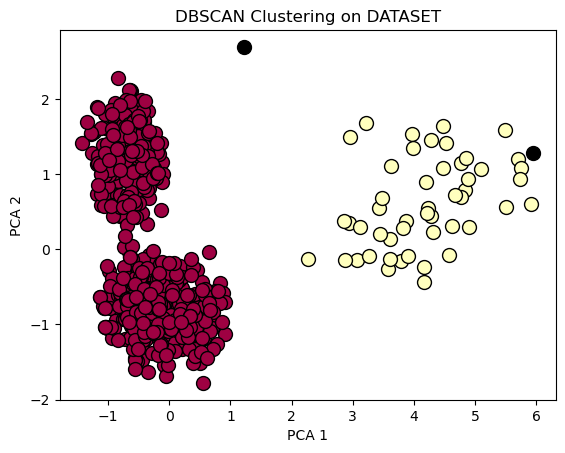

In [ ]:
unique_labels=set(labels)

colors= [plt.cm.Spectral(each) for each in np.linspace(0,1, len(unique_labels))]



for k, col in zip(unique_labels,colors):
    if k==-1:
        col=[0,0,0,1]

    class_member_mask = (labels==k)
    xy = pca_scaled[class_member_mask]
    plt.plot(xy[:,0], xy[:,1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=10)


plt.title('DBSCAN Clustering on DATASET')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [ ]:
unique_labels

{np.int64(-1), np.int64(0), np.int64(1)}


<div style="background-color:#111; color:#b300ffff; font-weight:700; padding:18px; border-radius:18px; text-align:center; font-size:40px; border:2px solid #b300ffff;">
HIERARCHICAL CLUSTERING
</div>

<div style="background-color: #263238; color: #eceff1; font-weight: bold; padding: 5px; border-radius: 15px; text-align: center; font-size: 30px;">
DENDROGRAM
</div>

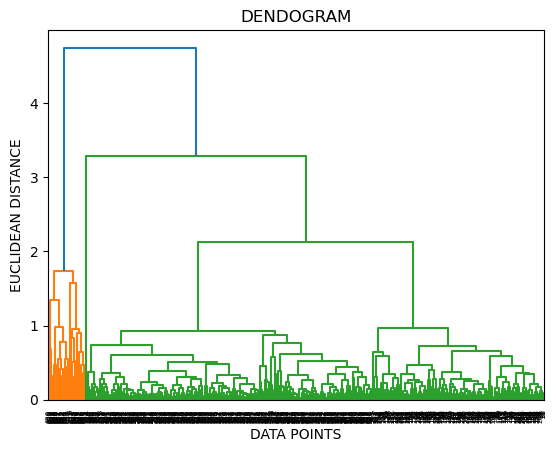

In [ ]:
dendogram=sch.dendrogram(sch.linkage(pca_scaled,method='average'))

plt.title('DENDOGRAM')
plt.xlabel('DATA POINTS')
plt.ylabel('EUCLIDEAN DISTANCE')
plt.show()

<div style="background-color: #263238; color: #eceff1; font-weight: bold; padding: 5px; border-radius: 15px; text-align: center; font-size: 30px;">
AGGLOMERATIVE CLUSTERING
</div>

In [ ]:
ahc=AgglomerativeClustering(n_clusters=2,linkage='average',metric='euclidean')
y_ahc=ahc.fit_predict(pca_scaled)
s_ahc=silhouette_score(pca_scaled,y_ahc)
s_ahc

np.float64(0.7078165839654764)

In [ ]:
y_ahc

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,


<div style="background-color:#111; color:#b300ffff; font-weight:700; padding:18px; border-radius:18px; text-align:center; font-size:40px; border:2px solid #b300ffff;">
FUZZY CLUSTERING
</div>

In [ ]:
t_data=pca_scaled.T

In [ ]:
jm_value=[]
cluster_range= range(2,11)

for c in cluster_range:
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        data= t_data,
        c= c,
        m= 2,
        error= 0.005,
        maxiter= 1000,
        init= None
    )

    jm_value.append(jm[-1])

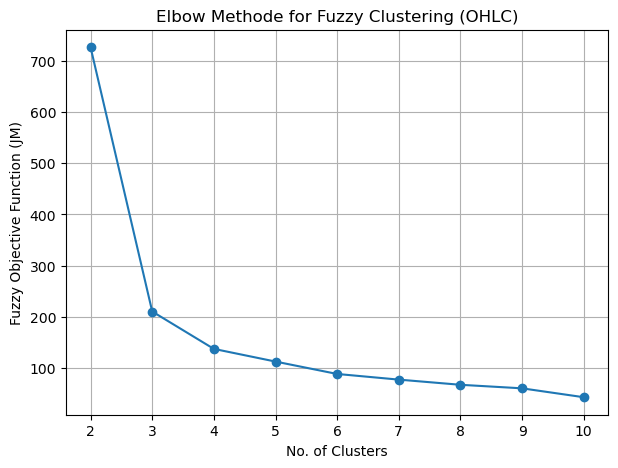

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(cluster_range, jm_value, marker='o')
plt.title('Elbow Methode for Fuzzy Clustering (OHLC)')
plt.xlabel('No. of Clusters')
plt.ylabel('Fuzzy Objective Function (JM)')
plt.grid(True)
plt.show()


In [ ]:
n_clusters = 3

cntr, u, u0, d, jm, p, fpc= fuzz.cluster.cmeans(
    data = t_data,
    c = n_clusters,
    m = 2,
    error = 0.005,
    maxiter =1000
)

hard_clusters = np.argmax(u, axis=0)

s_fuzz = silhouette_score(pca_scaled, hard_clusters)
s_fuzz

np.float64(0.6688032611366299)

In [ ]:
fpc

np.float64(0.8626547154769265)

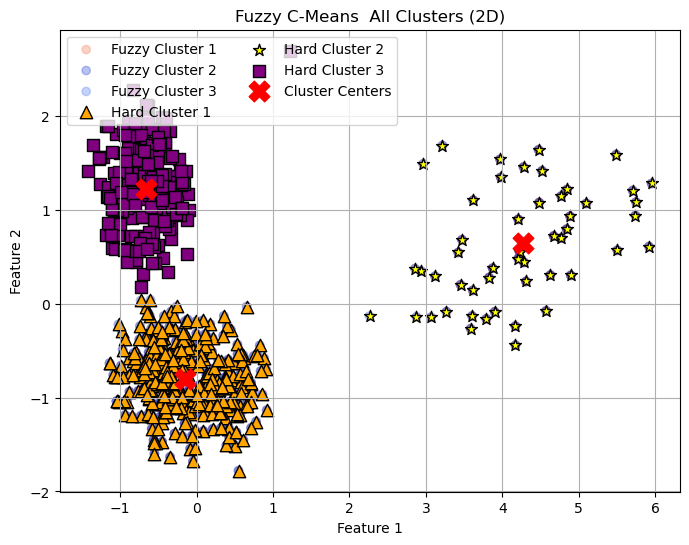

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))

for i in range(n_clusters):
    ax.scatter(
        t_data[0],
        t_data[1],
        c = u[i],
        cmap ='coolwarm',
        alpha =0.4,
        label =f'Fuzzy Cluster {i+1}'
    )

hard_clusters= np.argmax(u, axis=0)

markers = ['^', '*', 's']
colors = ['orange', 'yellow', 'purple']

for i in range(n_clusters):
    cluster_points = t_data[:, hard_clusters == i]
    ax.scatter(
        cluster_points[0],
        cluster_points[1],
        c = colors[i],
        marker = markers[i],
        edgecolor = 'k',
        s=80,
        label = f'Hard Cluster {i+1}'
    )

ax.scatter(
    cntr[:,0],
    cntr[:,1],
    c = 'red',
    marker= 'X',
    s=220,
    label='Cluster Centers'
)

ax.set_title('Fuzzy C-Means  All Clusters (2D)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(loc='upper left', ncol=2)
ax.grid(True)

plt.show()

<div style="background-color: #263238; color: #eceff1; font-weight: bold; padding: 5px; border-radius: 15px; text-align: center; font-size: 30px;">
TABLE
</div>

In [ ]:
table = [
    ['Clustering Method', 'Silhouette Score'],
    ['KMeans', s],
    ['DBSCAN', s_db],
    ['Agglomerative', s_ahc],
    ['Fuzzy C-Means', s_fuzz],

]

print(tabulate(table, headers='firstrow', tablefmt='fancy_grid'))

╒═════════════════════╤════════════════════╕
│ Clustering Method   │   Silhouette Score │
╞═════════════════════╪════════════════════╡
│ KMeans              │           0.770112 │
├─────────────────────┼────────────────────┤
│ DBSCAN              │           0.68008  │
├─────────────────────┼────────────────────┤
│ Agglomerative       │           0.707817 │
├─────────────────────┼────────────────────┤
│ Fuzzy C-Means       │           0.668803 │
╘═════════════════════╧════════════════════╛



<div style="background-color:#111; color:#b300ffff; font-weight:700; padding:18px; border-radius:18px; text-align:center; font-size:40px; border:2px solid #b300ffff;">
CLUSTERED DATASET
</div>

In [ ]:
df['CLUSTER']=y_kmeans
df

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,CLUSTER
0,100000,2,1,1,0,1
1,50000,3,0,10,9,0
2,50000,7,1,3,4,0
3,30000,5,1,1,4,0
4,100000,6,0,12,3,1
...,...,...,...,...,...,...
655,99000,10,1,10,0,1
656,84000,10,1,13,2,1
657,145000,8,1,9,1,1
658,172000,10,1,15,0,1


In [ ]:
cluster_1=df.loc[df['CLUSTER']==0]
cluster_1.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,CLUSTER
1,50000,3,0,10,9,0
2,50000,7,1,3,4,0
3,30000,5,1,1,4,0
5,20000,3,0,1,8,0
7,15000,3,0,1,1,0


In [ ]:
cluster_1.describe()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,CLUSTER
count,609.000000,609.000000,609.000000,609.000000,609.000000,609.0
mean,25725.779967,4.379310,2.553366,1.927750,3.794745,0.0
std,20521.218370,1.872314,1.604125,1.597089,2.873238,0.0
min,3000.000000,1.000000,0.000000,0.000000,0.000000,0.0
25%,10000.000000,3.000000,1.000000,1.000000,1.000000,0.0
50%,17000.000000,4.000000,2.000000,2.000000,3.000000,0.0
75%,39000.000000,6.000000,4.000000,3.000000,6.000000,0.0
max,75000.000000,7.000000,5.000000,10.000000,10.000000,0.0


In [ ]:
cluster_2=df.loc[df['CLUSTER']==1]
cluster_2.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,CLUSTER
0,100000,2,1,1,0,1
4,100000,6,0,12,3,1
6,100000,5,0,11,2,1
612,157000,9,1,14,1,1
613,94000,9,1,11,0,1


In [ ]:
cluster_2.describe()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,CLUSTER
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.0
mean,140235.294118,8.607843,0.607843,10.705882,1.058824,1.0
std,34592.246666,1.575797,0.493089,3.170452,0.881176,0.0
min,84000.000000,2.000000,0.000000,1.000000,0.000000,1.0
25%,107000.000000,8.000000,0.000000,8.000000,0.000000,1.0
50%,145000.000000,9.000000,1.000000,11.000000,1.000000,1.0
75%,169000.000000,10.000000,1.000000,13.000000,2.000000,1.0
max,200000.000000,10.000000,1.000000,15.000000,3.000000,1.0


<table style="border-collapse: collapse; width: 100%; font-size: 15px; color:black;">
  
  <!-- Heading -->
  <tr style="background-color:#b7e4c7; text-align:center;">
    <th style="padding:10px;">Cluster</th>
    <th style="padding:10px;">No. of Customers</th>
    <th style="padding:10px;">Customer Type</th>
    <th style="padding:10px;">Key Characteristics</th>
    <th style="padding:10px; background-color:#91d7a6ff;">
      Business Insight
    </th>
    
    
  </tr>

  <!-- Cluster 0 -->
  <tr style="background-color:#ced8e1ff;">
    <td style="padding:10px; text-align:center;"><b>Cluster 1</b></td>
    <td style="padding:10px; text-align:center;">609</td>
    <td style="padding:10px;">Low to Medium Value Customers</td>
    <td style="padding:10px;">
      • Lower average credit limit<br>
      • Fewer credit cards<br>
      • More bank visits<br>
      • Less online usage<br>
      • More customer service calls
    </td>
    <td style="padding:15px; background-color:#e9f5ff;"><b>
      • Depend more on offline banking<br><br>
      • Need more guidance and support<br><br>
      • Suitable for digital banking awareness programs
    <b></td>
  </tr>

  <!-- Cluster 1 -->
  <tr style="background-color:#ced8e1ff;">
    <td style="padding:10px; text-align:center;"><b>Cluster 2</b></td>
    <td style="padding:10px; text-align:center;">51</td>
    <td style="padding:10px;">High-Value / Premium Customers</td>
    <td style="padding:10px;">
      • Very high credit limit<br>
      • Many credit cards<br>
      • Rare bank visits<br>
      • High online usage<br>
      • Very few calls
    </td>
    <td style="padding:15px; background-color:#e9f5ff;"><b>
      • Digitally active and independent<br><br>
      • Comfortable with online services<br><br>
      • Ideal for premium offers and loyalty programs
    <b></td>
  </tr>

</table>